## Using customer purchase prediction.

- Goal: predict whether a customer buys a product
- 0 = No, 1 = Yes
- More time on website → higher chance of buying
- Supervised Machine Learning (they have labels attached to the dataset)
  - Regression / Classification (Logistic Regression) / RandomForest/ Decision Trees
- Unsupervised Machine Learning (they do not have labels attached)
  - KMeans (Clustering)
  - KNN (Nearest Neighbor)
- Reinforcement Learning
- Neural Networks 
  - Deep Learning /

## Feature:
- amount of time spent on website
- Bought Product

In [1]:
import torch
import torch.nn as nn

In [2]:
# Input feature
X = torch.tensor([
    [5.0],
    [10.0],
    [15.0],
    [20.0],
    [25.0],
    [30.0]
])

# Labels
y = torch.tensor([
    [0.0],
    [0.0],
    [0.0],
    [1.0],
    [1.0],
    [1.0]
])


In [3]:
# Model
class LogisticRegression(nn.Module):

    def __init__(self):
        super().__init__()

        self.linear = nn.Linear(1, 1)

    def forward(self, x):

        logits = self.linear(x) # y = wx + b

        return logits

In [4]:
# Create model
model = LogisticRegression()

In [5]:
# Loss function
loss_fn = nn.BCEWithLogitsLoss()

# Optimizer
optimizer = torch.optim.SGD(model.parameters(),lr=0.01)

In [6]:
# Training
epochs = 1000

for epoch in range(epochs):

    # Forward pass
    logits = model(X)

    # Loss
    loss = loss_fn(logits, y)

    # Zero gradients
    optimizer.zero_grad()

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 4.8923
Epoch 100, Loss: 0.5845
Epoch 200, Loss: 0.5577
Epoch 300, Loss: 0.5331
Epoch 400, Loss: 0.5107
Epoch 500, Loss: 0.4901
Epoch 600, Loss: 0.4712
Epoch 700, Loss: 0.4538
Epoch 800, Loss: 0.4378
Epoch 900, Loss: 0.4230


In [7]:
# Test prediction
test = torch.tensor([[2.0]])

with torch.no_grad():

    logits = model(test)
    print("\nLogits:", logits.item())

    probability = torch.sigmoid(logits)

    print("\nProbability of purchase:")
    print(f"{probability.item():.4f}")

    threshold = 0.5
    prediction = 1 if probability >= threshold else 0

    print("Predicted Class:", prediction)


Logits: -1.199950098991394

Probability of purchase:
0.2315
Predicted Class: 0


## Sigmoid Activation Function

In [12]:
def sigmoid(x):
    return 1 / (1 + torch.exp(-x))

m = nn.Sigmoid()

x = torch.tensor([0.0])
print("\nSigmoid of 0:", sigmoid(x).item())

x = torch.tensor([-1.1525766849517822])
print("\nSigmoid of -1.15:", sigmoid(x).item())

print("\nSigmoid of -1.15 (using nn.Sigmoid()):", m(x).item())



Sigmoid of 0: 0.5

Sigmoid of -1.15: 0.24001877009868622

Sigmoid of -1.15 (using nn.Sigmoid()): 0.24001877009868622


In [ ]:
m = nn.Sigmoid()
input = torch.randn(2)
output = m(input)

print("\nInput:", input)
print("\nOutput:", output)


Input: tensor([ 1.8298, -0.5769])

Output: tensor([0.8617, 0.3596])


In [9]:
# plot sigmoid function
import matplotlib.pyplot as plt


x = torch.linspace(-10, 10, 100)
print(x)

y = sigmoid(x)
print(y)


tensor([-10.0000,  -9.7980,  -9.5960,  -9.3939,  -9.1919,  -8.9899,  -8.7879,
         -8.5859,  -8.3838,  -8.1818,  -7.9798,  -7.7778,  -7.5758,  -7.3737,
         -7.1717,  -6.9697,  -6.7677,  -6.5657,  -6.3636,  -6.1616,  -5.9596,
         -5.7576,  -5.5556,  -5.3535,  -5.1515,  -4.9495,  -4.7475,  -4.5455,
         -4.3434,  -4.1414,  -3.9394,  -3.7374,  -3.5354,  -3.3333,  -3.1313,
         -2.9293,  -2.7273,  -2.5253,  -2.3232,  -2.1212,  -1.9192,  -1.7172,
         -1.5152,  -1.3131,  -1.1111,  -0.9091,  -0.7071,  -0.5051,  -0.3030,
         -0.1010,   0.1010,   0.3030,   0.5051,   0.7071,   0.9091,   1.1111,
          1.3131,   1.5152,   1.7172,   1.9192,   2.1212,   2.3232,   2.5253,
          2.7273,   2.9293,   3.1313,   3.3333,   3.5354,   3.7374,   3.9394,
          4.1414,   4.3434,   4.5455,   4.7475,   4.9495,   5.1515,   5.3535,
          5.5556,   5.7576,   5.9596,   6.1616,   6.3636,   6.5657,   6.7677,
          6.9697,   7.1717,   7.3737,   7.5758,   7.7778,   7.97

In [11]:
x = torch.tensor([-10.0, 0.0, 10.0])
y = sigmoid(x)
print(y)

tensor([4.5398e-05, 5.0000e-01, 9.9995e-01])


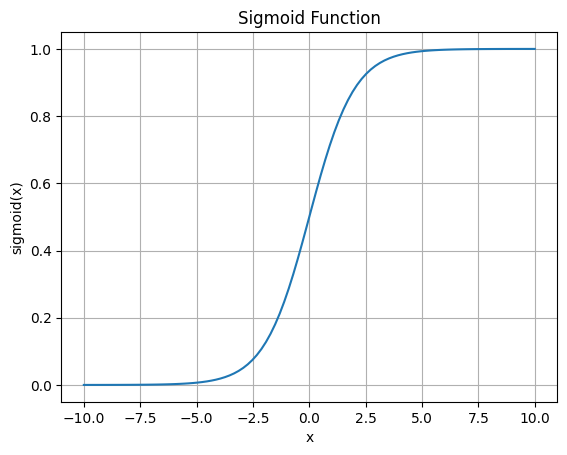

In [10]:
plt.plot(x.detach().numpy(), y.detach().numpy())
plt.xlabel("x")
plt.ylabel("sigmoid(x)")
plt.title("Sigmoid Function")
plt.grid(True)
plt.show()

## Other Activation functions
- ReLU
- Tanh
- Softmax
- LeakyReLU

In [14]:
def tanh(x):
    return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))


m = nn.Tanh()
input = torch.randn(2)
output = m(input)

print("\nInput:", input)
print("\nOutput:", output)


Input: tensor([-1.2877,  1.3597])

Output: tensor([-0.8585,  0.8763])


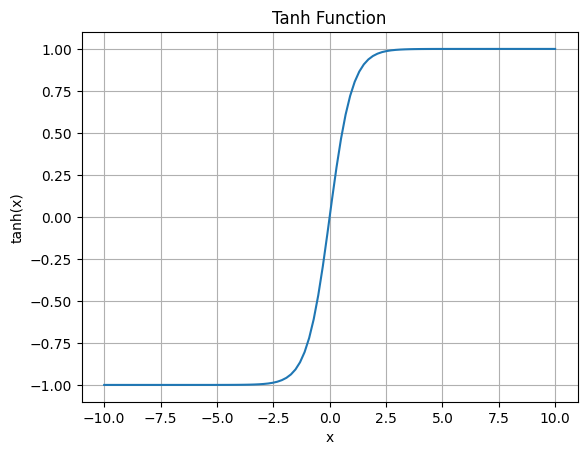

In [15]:
# plot tanh function
x = torch.linspace(-10, 10, 100)
y = tanh(x)

plt.plot(x.detach().numpy(), y.detach().numpy())
plt.xlabel("x")
plt.ylabel("tanh(x)")
plt.title("Tanh Function")
plt.grid(True)
plt.show()

## ReLU

In [19]:
def relu(x):
    return torch.maximum(torch.tensor(0.0), x)

x = torch.randn(10)
print("\nRandom tensor:", x)

y = relu(x)
print("\nReLU of random tensor:", y)



Random tensor: tensor([ 2.3017,  0.7641,  1.4267,  1.6136,  0.6318, -1.3561, -0.1019,  0.2892,
         0.8821, -0.5310])

ReLU of random tensor: tensor([2.3017, 0.7641, 1.4267, 1.6136, 0.6318, 0.0000, 0.0000, 0.2892, 0.8821,
        0.0000])


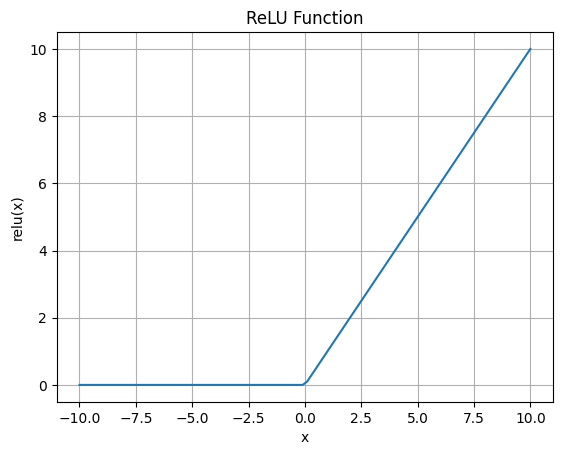

In [20]:
# plot relu function
x = torch.linspace(-10, 10, 100)
y = relu(x)

plt.plot(x.detach().numpy(), y.detach().numpy())
plt.xlabel("x")
plt.ylabel("relu(x)")
plt.title("ReLU Function")
plt.grid(True)
plt.show()

## Softmax activation function
- Used for multi-class classification problems
- it should also sum-up to 1.0

In [22]:
def softmax(x):
    exp_x = torch.exp(x)
    print("\nExponentiated x:", exp_x)
    sum_exp_x = torch.sum(exp_x)
    print("\nSum of exponentiated x:", sum_exp_x)
    return exp_x / sum_exp_x


x = torch.tensor([0.1, 1.0, 2.0])
print("\nSoftmax of x:", softmax(x))




Exponentiated x: tensor([1.1052, 2.7183, 7.3891])

Sum of exponentiated x: tensor(11.2125)

Softmax of x: tensor([0.0986, 0.2424, 0.6590])


In [23]:
0.0986 + 0.2424 + 0.6590

1.0

In [29]:
x = torch.tensor([0.1, 1.0, 2.0])

print(torch.max(x, dim=0))

torch.return_types.max(
values=tensor(2.),
indices=tensor(2))



Exponentiated x: tensor([4.5400e-05, 5.5564e-05, 6.8003e-05, 8.3227e-05, 1.0186e-04, 1.2466e-04,
        1.5257e-04, 1.8673e-04, 2.2853e-04, 2.7969e-04, 3.4231e-04, 4.1894e-04,
        5.1273e-04, 6.2752e-04, 7.6800e-04, 9.3994e-04, 1.1504e-03, 1.4079e-03,
        1.7231e-03, 2.1088e-03, 2.5810e-03, 3.1588e-03, 3.8659e-03, 4.7314e-03,
        5.7906e-03, 7.0870e-03, 8.6736e-03, 1.0615e-02, 1.2992e-02, 1.5900e-02,
        1.9460e-02, 2.3817e-02, 2.9148e-02, 3.5674e-02, 4.3660e-02, 5.3435e-02,
        6.5397e-02, 8.0038e-02, 9.7956e-02, 1.1989e-01, 1.4673e-01, 1.7957e-01,
        2.1977e-01, 2.6898e-01, 3.2919e-01, 4.0289e-01, 4.9309e-01, 6.0347e-01,
        7.3858e-01, 9.0392e-01, 1.1063e+00, 1.3540e+00, 1.6571e+00, 2.0280e+00,
        2.4821e+00, 3.0377e+00, 3.7178e+00, 4.5501e+00, 5.5688e+00, 6.8155e+00,
        8.3412e+00, 1.0209e+01, 1.2494e+01, 1.5291e+01, 1.8714e+01, 2.2904e+01,
        2.8032e+01, 3.4307e+01, 4.1988e+01, 5.1387e+01, 6.2892e+01, 7.6971e+01,
        9.4203e+01, 1.

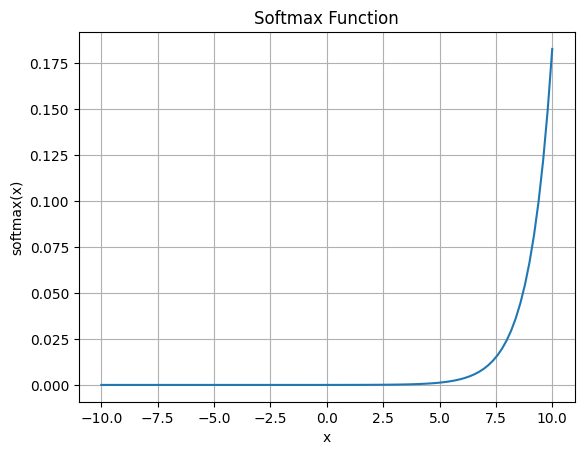

In [24]:
# plot softmax function
x = torch.linspace(-10, 10, 100)
y = softmax(x)

plt.plot(x.detach().numpy(), y.detach().numpy())
plt.xlabel("x")
plt.ylabel("softmax(x)")
plt.title("Softmax Function")
plt.grid(True)
plt.show()